[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/himanshu231204/pytorch-mastery/blob/main/02_core_deep_learning/05_initialization/initialization.ipynb)

# 11 . Weight Initialization

## Concept — Weight Initialization (revision notes)

**What it is**
- The choice of starting values for a network's weights (and biases) before training.
- PyTorch's `torch.nn.init` provides standard schemes: Xavier/Glorot, Kaiming/He, orthogonal, plain normal/uniform, zeros, constants.

**Why it matters**
- Identical weights make neurons identical forever (symmetry), so they must be random.
- Too small a scale -> signals and gradients shrink layer by layer (vanishing). Too large -> they blow up (exploding) or saturate tanh/sigmoid. Either way a deep network may not train at all.
- Good init keeps the variance of activations and gradients roughly constant from layer to layer, so training starts in a healthy regime.

**When to use**
- The default `nn.Linear` / `nn.Conv2d` init is sensible; override it when you use deep stacks, a specific activation (ReLU -> Kaiming, tanh -> Xavier), residual branches, or when reproducing a paper.

**Math & intuition**
- One layer: `y = W x`, with `fan_in` inputs, independent zero-mean weights of variance `Var(w)`: `Var(y) = fan_in * Var(w) * E[x^2]`. To keep `Var(y) = Var(x)` we need `Var(w) = 1/fan_in`.
- Xavier (Glorot) balances forward and backward: `Var(w) = 2 / (fan_in + fan_out)`. Designed for roughly linear or tanh units.
- Kaiming (He): ReLU zeroes half the activations, halving the second moment, so compensate with `Var(w) = 2 / fan_in` (std = gain / sqrt(fan)), gain = sqrt(2) for ReLU.
- Orthogonal init: weight matrices with all singular values 1 preserve vector norms exactly through depth.
- Biases are usually 0. Residual branches' last layer is often zero-initialised so each block starts as the identity.

### 1. What PyTorch does by default

**What this cell does (plain language):** we create an `nn.Linear` and look at the range of its weights. PyTorch's default is `kaiming_uniform_(a=sqrt(5))`, which works out to a uniform distribution on `[-1/sqrt(fan_in), +1/sqrt(fan_in)]`, so we compare the measured min/max/std with that formula.

In [1]:
import math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt

torch.set_num_threads(1)     # tiny models: threading overhead costs more than it saves
torch.manual_seed(0)

fan_in, fan_out = 512, 256
lin = nn.Linear(fan_in, fan_out)
bound = 1 / math.sqrt(fan_in)
w = lin.weight.detach()
print(f"formula bound 1/sqrt(fan_in) = {bound:.4f}")
print(f"weight min {w.min():.4f} | max {w.max():.4f} | std {w.std():.4f}  (uniform std = bound/sqrt(3) = {bound / math.sqrt(3):.4f})")
print(f"bias   min {lin.bias.min():.4f} | max {lin.bias.max():.4f}  (also within +-{bound:.4f}, NOT zero by default)")
print("weight shape is (out_features, in_features):", tuple(w.shape))

formula bound 1/sqrt(fan_in) = 0.0442
weight min -0.0442 | max 0.0442 | std 0.0255  (uniform std = bound/sqrt(3) = 0.0255)
bias   min -0.0439 | max 0.0439  (also within +-0.0442, NOT zero by default)
weight shape is (out_features, in_features): (256, 512)


### 2. Symmetry problem: constant init never breaks ties

**What this cell does (plain language):** we initialise every weight in a 2-layer network to the same constant, take a few optimisation steps, and look at the hidden layer. Every hidden unit receives the same gradient so they stay identical copies of each other: the layer is effectively 1 neuron wide no matter how many units it has.

In [2]:
torch.manual_seed(0)
net = nn.Sequential(nn.Linear(4, 8), nn.Tanh(), nn.Linear(8, 1))
for p in net.parameters():
    nn.init.constant_(p, 0.5)                             # same value everywhere

x, y = torch.randn(64, 4), torch.randn(64, 1)
opt = torch.optim.SGD(net.parameters(), lr=0.1)
for _ in range(20):
    opt.zero_grad(); F.mse_loss(net(x), y).backward(); opt.step()

W1 = net[0].weight.detach()
print("hidden weight rows (first 3 units, first 3 inputs):\n", W1[:3, :3])
print("all 8 hidden units still identical:", all(torch.allclose(W1[0], W1[i]) for i in range(8)))
print("gradient rows identical too:", torch.allclose(net[0].weight.grad[0], net[0].weight.grad[5]))

hidden weight rows (first 3 units, first 3 inputs):
 tensor([[0.4500, 0.4591, 0.4791],
        [0.4500, 0.4591, 0.4791],
        [0.4500, 0.4591, 0.4791]])
all 8 hidden units still identical: True
gradient rows identical too: True


### 3. Forward activations through 30 tanh layers

**What this cell does (plain language):** we stack 30 tanh layers (width 256) and push random inputs through, printing the standard deviation of the activations at several depths. With weights that are too small the signal fades toward 0; too large and tanh saturates at +-1; Xavier keeps it in a healthy range.

In [3]:
def deep_stats(init_fn, act=torch.tanh, depth=30, width=256, n=512, seed=0):
    torch.manual_seed(seed)
    h = torch.randn(n, width)
    stds = []
    for _ in range(depth):
        W = torch.empty(width, width)
        init_fn(W)
        h = act(h @ W.T)                                   # bias omitted to isolate the weight scale
        stds.append(h.std().item())
    return stds

inits = {
    "N(0, 0.01)  too small": lambda W: nn.init.normal_(W, std=0.01),
    "N(0, 1)     too large": lambda W: nn.init.normal_(W, std=1.0),
    "Xavier normal":         lambda W: nn.init.xavier_normal_(W),
}
for name, f in inits.items():
    s = deep_stats(f)
    print(f"{name:24s} activation std at layers 1/5/10/20/30: " + " | ".join(f"{s[i-1]:.4f}" for i in (1, 5, 10, 20, 30)))

N(0, 0.01)  too small    activation std at layers 1/5/10/20/30: 0.1559 | 0.0001 | 0.0000 | 0.0000 | 0.0000
N(0, 1)     too large    activation std at layers 1/5/10/20/30: 0.9750 | 0.9746 | 0.9737 | 0.9742 | 0.9741
Xavier normal            activation std at layers 1/5/10/20/30: 0.6278 | 0.3239 | 0.2239 | 0.1522 | 0.1285


### 4. The same for ReLU: Xavier vs Kaiming

**What this cell does (plain language):** we repeat the depth experiment with ReLU. Xavier ignores that ReLU kills half the signal, so activations shrink every layer; Kaiming adds the missing factor of 2 and holds the scale steady. This is why you match the init to the activation.

Xavier normal  (ReLU)    std at layers 1/5/10/20/30: 0.5808 | 0.1182 | 0.0206 | 0.0005 | 0.0000


Kaiming normal (ReLU)    std at layers 1/5/10/20/30: 0.8214 | 0.6685 | 0.6595 | 0.4906 | 0.4891


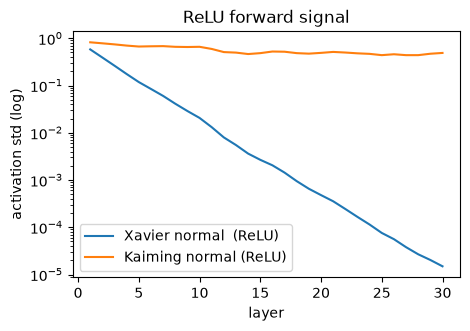

In [4]:
relu = torch.relu
configs = {
    "Xavier normal  (ReLU)": lambda W: nn.init.xavier_normal_(W),
    "Kaiming normal (ReLU)": lambda W: nn.init.kaiming_normal_(W, nonlinearity="relu"),
}
series = {}
for name, f in configs.items():
    series[name] = deep_stats(f, act=relu)
    s = series[name]
    print(f"{name:24s} std at layers 1/5/10/20/30: " + " | ".join(f"{s[i-1]:.4f}" for i in (1, 5, 10, 20, 30)))

plt.figure(figsize=(5, 3.2))
for name, s in series.items(): plt.semilogy(range(1, 31), s, label=name)
plt.xlabel("layer"); plt.ylabel("activation std (log)"); plt.legend(); plt.title("ReLU forward signal"); plt.show()

### 5. Checking the variance formula directly

**What this cell does (plain language):** we verify the one-layer rule `Var(y) = fan_in * Var(w) * E[x^2]` numerically for a single large layer, and show that choosing `Var(w) = 2/fan_in` (Kaiming) restores the second moment after a ReLU. Seeing the arithmetic match is what makes the init formulas feel less like magic.

In [5]:
torch.manual_seed(0)
n, fan_in, fan_out = 4096, 1024, 1024
x = torch.randn(n, fan_in)                                  # E[x^2] = 1
for std in (0.5 / math.sqrt(fan_in), 1.0 / math.sqrt(fan_in), 2.0 / math.sqrt(fan_in)):
    W = torch.randn(fan_out, fan_in) * std
    y = x @ W.T
    print(f"Var(w)={std**2:.2e} | measured Var(y)={y.var():.3f} | predicted fan_in*Var(w)*E[x^2]={fan_in * std**2:.3f}")

W = torch.randn(fan_out, fan_in) * math.sqrt(2.0 / fan_in)  # Kaiming
a = torch.relu(x @ W.T)
print(f"Kaiming: E[x^2]={x.pow(2).mean():.3f} -> E[relu(y)^2]={a.pow(2).mean():.3f}  (second moment preserved through the ReLU)")

Var(w)=2.44e-04 | measured Var(y)=0.250 | predicted fan_in*Var(w)*E[x^2]=0.250
Var(w)=9.77e-04 | measured Var(y)=0.999 | predicted fan_in*Var(w)*E[x^2]=1.000


Var(w)=3.91e-03 | measured Var(y)=3.991 | predicted fan_in*Var(w)*E[x^2]=4.000


Kaiming: E[x^2]=1.000 -> E[relu(y)^2]=1.001  (second moment preserved through the ReLU)


### 6. The torch.nn.init toolbox: gain, fan_in vs fan_out

**What this cell does (plain language):** we call the standard init functions and compare the resulting weight std with the closed-form formulas. We also look at `calculate_gain` for different activations and at `mode='fan_in'` vs `'fan_out'` on a non-square layer, since the two give different scales.

In [6]:
torch.manual_seed(0)
W = torch.empty(300, 100)                                  # (fan_out=300, fan_in=100)
fo, fi = W.shape
nn.init.xavier_uniform_(W);                       print(f"xavier_uniform  std {W.std():.4f} | formula sqrt(2/(fi+fo)) = {math.sqrt(2/(fi+fo)):.4f}")
nn.init.xavier_normal_(W);                        print(f"xavier_normal   std {W.std():.4f} | formula sqrt(2/(fi+fo)) = {math.sqrt(2/(fi+fo)):.4f}")
nn.init.kaiming_normal_(W, mode="fan_in", nonlinearity="relu");  print(f"kaiming fan_in  std {W.std():.4f} | formula sqrt(2/fan_in)   = {math.sqrt(2/fi):.4f}")
nn.init.kaiming_normal_(W, mode="fan_out", nonlinearity="relu"); print(f"kaiming fan_out std {W.std():.4f} | formula sqrt(2/fan_out)  = {math.sqrt(2/fo):.4f}")

print("\nrecommended gains:")
for name, kw in [("linear", {}), ("sigmoid", {}), ("tanh", {}), ("relu", {}), ("leaky_relu", {"param": 0.1})]:
    print(f"  {name:11s} {nn.init.calculate_gain(name, **kw):.4f}")

xavier_uniform  std 0.0705 | formula sqrt(2/(fi+fo)) = 0.0707
xavier_normal   std 0.0704 | formula sqrt(2/(fi+fo)) = 0.0707
kaiming fan_in  std 0.1422 | formula sqrt(2/fan_in)   = 0.1414
kaiming fan_out std 0.0818 | formula sqrt(2/fan_out)  = 0.0816

recommended gains:
  linear      1.0000
  sigmoid     1.0000
  tanh        1.6667
  relu        1.4142
  leaky_relu  1.4072


### 7. Backward pass: gradient norms per layer

**What this cell does (plain language):** we build a 20-layer ReLU MLP under three inits (tiny, huge, Kaiming), run one backward pass, and print the gradient norm of the first, middle and last layers. Healthy init gives gradients of comparable size everywhere; bad init makes early layers get gradients that are 0 or astronomically large.

In [7]:
def make_deep(init, depth=20, width=128):
    layers = []
    for _ in range(depth):
        lin = nn.Linear(width, width)
        init(lin.weight); nn.init.zeros_(lin.bias)
        layers += [lin, nn.ReLU()]
    return nn.Sequential(*layers, nn.Linear(width, 1))

torch.manual_seed(0)
x, y = torch.randn(256, 128), torch.randn(256, 1)
for name, init in [("std 0.01", lambda w: nn.init.normal_(w, std=0.01)),
                   ("std 0.3 ", lambda w: nn.init.normal_(w, std=0.3)),
                   ("kaiming ", lambda w: nn.init.kaiming_normal_(w, nonlinearity="relu"))]:
    torch.manual_seed(0)
    m = make_deep(init)
    F.mse_loss(m(x), y).backward()
    lins = [l for l in m if isinstance(l, nn.Linear)]
    g = [l.weight.grad.norm().item() for l in lins]
    print(f"{name} | grad norm first {g[0]:.2e} | middle {g[len(g)//2]:.2e} | last {g[-1]:.2e}")

std 0.01 | grad norm first 0.00e+00 | middle 4.99e-22 | last 1.67e-22
std 0.3  | grad norm first 1.53e+14 | middle 9.38e+14 | last 1.28e+16
kaiming  | grad norm first 5.53e-01 | middle 1.62e+00 | last 9.41e+00


### 8. Custom initialization with model.apply()

**What this cell does (plain language):** we write an `init_weights` function that picks the right scheme by layer type, and call `model.apply(fn)`, which visits every submodule recursively. This is the idiomatic way to initialise a whole model consistently, and we verify the result by checking biases are zero and weight std matches Kaiming.

In [8]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, (nn.BatchNorm1d, nn.LayerNorm)):
        nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

torch.manual_seed(0)
model = nn.Sequential(nn.Linear(100, 200), nn.LayerNorm(200), nn.ReLU(), nn.Linear(200, 10))
model.apply(init_weights)                                  # recursively applied to every submodule
print("layer0 weight std", round(model[0].weight.std().item(), 4), "| kaiming target", round(math.sqrt(2 / 100), 4))
print("all linear biases zero:", all(torch.count_nonzero(m.bias) == 0 for m in model if isinstance(m, nn.Linear)))
print("LayerNorm weight/bias:", model[1].weight.mean().item(), model[1].bias.mean().item())

layer0 weight std 0.141 | kaiming target 0.1414
all linear biases zero: True
LayerNorm weight/bias: 1.0 0.0


### 9. Does it matter for training? Deep MLP, three inits

**What this cell does (plain language):** we train the same 20-layer ReLU MLP on a synthetic regression task with plain SGD, starting from a too-small init, the PyTorch default, and Kaiming. We print the loss after a fixed number of steps. Differences are largest for deep nets trained with plain SGD, where init quality directly sets how fast learning starts. Note PyTorch's default is tuned for shallow nets (variance 1/(3*fan_in)), so a 20-layer ReLU stack without normalisation is exactly where it falls short.

In [9]:
torch.manual_seed(0)
Xr = torch.randn(512, 128)
w_t = torch.randn(128, 1) / math.sqrt(128)
yr = torch.tanh(Xr @ w_t) + 0.05 * torch.randn(512, 1)

def train_with(init, steps=200, lr=0.01):
    torch.manual_seed(0)
    m = make_deep(init) if init is not None else None
    if m is None:                                          # PyTorch default init
        m = make_deep(lambda w: None)
        for l in m:
            if isinstance(l, nn.Linear): l.reset_parameters()
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    first = None
    for s in range(steps):
        opt.zero_grad(); loss = F.mse_loss(m(Xr), yr); loss.backward(); opt.step()
        first = first if first is not None else loss.item()
    return first, loss.item()

for name, init in [("normal std=0.01", lambda w: nn.init.normal_(w, std=0.01)),
                   ("PyTorch default", None),
                   ("kaiming normal ", lambda w: nn.init.kaiming_normal_(w, nonlinearity="relu"))]:
    a, b = train_with(init)
    print(f"{name} | loss step 0: {a:.4f} -> after 200 steps: {b:.4f}")
print("(target variance of y for reference:", round(yr.var().item(), 4), "- a loss near this means nothing was learned)")

normal std=0.01 | loss step 0: 0.3477 -> after 200 steps: 0.3465


PyTorch default | loss step 0: 0.3509 -> after 200 steps: 0.3465


kaiming normal  | loss step 0: 0.5041 -> after 200 steps: 0.0657
(target variance of y for reference: 0.3472 - a loss near this means nothing was learned)


### 10. Orthogonal init: exact norm preservation

**What this cell does (plain language):** we initialise a deep LINEAR stack with orthogonal matrices and with scaled-Gaussian matrices and measure how the norm of a vector changes through 50 layers. Orthogonal matrices have all singular values 1, so the norm stays constant; random Gaussian matrices let it drift because their singular values spread out.

In [10]:
torch.manual_seed(0)
width, depth = 128, 50
v0 = torch.randn(1, width); v_orth = v0.clone(); v_gauss = v0.clone()
for _ in range(depth):
    Wo = torch.empty(width, width); nn.init.orthogonal_(Wo)
    Wg = torch.randn(width, width) / math.sqrt(width)       # variance-preserving on average
    v_orth = v_orth @ Wo.T; v_gauss = v_gauss @ Wg.T
print(f"input norm {v0.norm():.3f} | after {depth} orthogonal layers {v_orth.norm():.3f} | after {depth} Gaussian layers {v_gauss.norm():.3f}")
print("singular values of one orthogonal W (min/max):", torch.linalg.svdvals(Wo).min().item(), torch.linalg.svdvals(Wo).max().item())

input norm 11.769 | after 50 orthogonal layers 11.769 | after 50 Gaussian layers 8.211
singular values of one orthogonal W (min/max): 0.9999997019767761 1.0000003576278687


### 11. Output layer and residual-branch init tricks

**What this cell does (plain language):** we show two practical tricks. First, shrinking the last classification layer makes the initial loss start at ln(K) (an honest 'I know nothing' prediction) instead of some random large value. Second, zero-initialising the last layer of a residual branch makes the block start as the identity function, which stabilises deep residual nets.

In [11]:
torch.manual_seed(0)
K = 10
xb, yb = torch.randn(256, 64), torch.randint(0, K, (256,))
for scale, name in [(1.0, "default"), (0.01, "last layer scaled by 0.01")]:
    head = nn.Sequential(nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, K))
    head[2].weight.data.mul_(scale); head[2].bias.data.zero_()
    print(f"{name:28s} initial CE loss = {F.cross_entropy(head(xb), yb).item():.4f}   (ln K = {math.log(K):.4f})")

class ResBlock(nn.Module):
    def __init__(self, d, zero_init=True):
        super().__init__()
        self.f = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, d))
        if zero_init:
            nn.init.zeros_(self.f[2].weight); nn.init.zeros_(self.f[2].bias)
    def forward(self, x): return x + self.f(x)

blk = ResBlock(64)
print("zero-init residual block is the identity at start:", torch.allclose(blk(xb), xb))
stack = nn.Sequential(*[ResBlock(64) for _ in range(50)])
print(f"50 stacked zero-init blocks: output == input -> {torch.allclose(stack(xb), xb)}  (a 50-deep net that begins as a trivially stable function)")

default                      initial CE loss = 2.3379   (ln K = 2.3026)
last layer scaled by 0.01    initial CE loss = 2.3027   (ln K = 2.3026)
zero-init residual block is the identity at start: True
50 stacked zero-init blocks: output == input -> True  (a 50-deep net that begins as a trivially stable function)


## Common bugs

- **Initialising all weights to the same value (zeros or a constant)** -> every unit in a layer gets identical gradients and stays identical. Fix: random init (biases may be 0).
- **Using a tiny `normal_(std=0.01)` on a deep network "to be safe"** -> activations and gradients vanish through depth. Fix: scale by fan-in (Xavier/Kaiming).
- **Xavier for ReLU nets** (or Kaiming gain for tanh) -> scale drifts each layer. Fix: Kaiming (`nonlinearity='relu'`) for ReLU-family, Xavier for tanh/sigmoid/linear.
- **Wrong `mode` / transposed shape thinking** -> `nn.Linear.weight` is `(out, in)`, so `fan_in` is the SECOND dimension. Fix: let `nn.init` compute fans from the tensor; use `mode='fan_in'` to preserve forward signals.
- **Initialising outside `torch.no_grad()` by arithmetic on `param`** -> in-place op on a leaf requiring grad raises an error. Fix: use `nn.init.*` (already no-grad) or `param.data` / `with torch.no_grad():`.
- **Calling `init_weights` on a model, then loading a checkpoint or re-creating layers** -> your init is overwritten or never applied to new layers. Fix: initialise after construction, before training; do not re-init pretrained weights unless intended.
- **Forgetting that `model.apply(fn)` also visits container modules** -> `fn` must check `isinstance`. Fix: guard on layer type.
- **Re-initialising only some layers of a pretrained model** with large std -> destroys features. Fix: small std for new heads, leave backbone alone.
- **Judging init by one random seed** -> a lucky draw can mask a poor scheme. Fix: look at activation/gradient statistics (as above), not just one loss number.

## Exercises

**Exercise 1 - Bounds of the default init.**
For `nn.Linear(100, 50)`, assert all weights lie in `[-1/sqrt(100), 1/sqrt(100)]`, and print the fraction of weights outside that range.

In [12]:
# Your attempt for Exercise 1 here

**Solution 1**

In [13]:
# Solution 1
l = nn.Linear(100, 50); b = 1 / math.sqrt(100)
print((l.weight.abs() <= b).all().item(), (l.weight.abs() > b).float().mean().item())

True 0.0


**Exercise 2 - Find the std that preserves variance.**
Empirically find the weight std that keeps the activation std roughly constant through 20 tanh layers of width 200, by trying 5 values around `1/sqrt(200)`.

In [14]:
# Your attempt for Exercise 2 here

**Solution 2**

In [15]:
# Solution 2
base = 1 / math.sqrt(200)
for mult in (0.5, 0.8, 1.0, 1.5, 2.0):
    def f(W, s=base * mult): nn.init.normal_(W, std=s)
    print(mult, round(deep_stats(f, depth=20, width=200)[-1], 4))
# Pick the multiplier where the final std is neither ~0 (vanished) nor close to ~1 (saturated); for tanh this
# lands above 1/sqrt(fan_in), consistent with the tanh gain of 5/3 used by calculate_gain.

0.5 0.0
0.8 0.0055
1.0 0.1557
1.5 0.5888
2.0 0.7252


**Exercise 3 - Leaky ReLU gain.**
Compute the Kaiming std for `LeakyReLU(0.2)` using `nn.init.calculate_gain('leaky_relu', 0.2)` and compare against `kaiming_normal_(a=0.2, nonlinearity='leaky_relu')` for fan_in = 256.

In [16]:
# Your attempt for Exercise 3 here

**Solution 3**

In [17]:
# Solution 3
g = nn.init.calculate_gain("leaky_relu", 0.2)
W = torch.empty(512, 256); nn.init.kaiming_normal_(W, a=0.2, nonlinearity="leaky_relu")
print("formula std", round(g / math.sqrt(256), 4), "| measured", round(W.std().item(), 4))

formula std 0.0867 | measured 0.0866


**Exercise 4 - Init every conv/linear in a model.**
Write an `apply`-style function that initialises `nn.Conv2d` with Kaiming and `nn.Linear` with Xavier, biases to zero. Test on a small model and print each layer's weight std.

In [18]:
# Your attempt for Exercise 4 here

**Solution 4**

In [19]:
# Solution 4
def init_mixed(m):
    if isinstance(m, nn.Conv2d): nn.init.kaiming_normal_(m.weight, nonlinearity="relu"); nn.init.zeros_(m.bias)
    elif isinstance(m, nn.Linear): nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)
net = nn.Sequential(nn.Conv2d(3, 8, 3), nn.ReLU(), nn.Flatten(), nn.Linear(8 * 6 * 6, 10))
net.apply(init_mixed)
print([round(m.weight.std().item(), 4) for m in net if hasattr(m, "weight")])

[0.3101, 0.0829]


**Exercise 5 - Detect vanishing activations automatically.**
Write a function using forward hooks that records activation std after every Linear+ReLU in a model and flags layers where std < 1e-3. Run it on the 'std 0.01' deep model.

In [20]:
# Your attempt for Exercise 5 here

**Solution 5**

In [21]:
# Solution 5
def activation_report(model, x):
    stats, hooks = [], []
    for i, m in enumerate(model):
        if isinstance(m, nn.ReLU):
            hooks.append(m.register_forward_hook(lambda mod, inp, out, i=i: stats.append((i, out.std().item()))))
    with torch.no_grad(): model(x)
    for h in hooks: h.remove()
    return [(i, s) for i, s in stats if s < 1e-3]
torch.manual_seed(0)
bad = make_deep(lambda w: nn.init.normal_(w, std=0.01))
print("flagged layers:", len(activation_report(bad, torch.randn(64, 128))), "of 20")

flagged layers: 18 of 20


**Exercise 6 - Bias init for imbalanced classes.**
For a binary classifier whose positive rate is 5%, initialise the output bias to `log(p/(1-p))` so the initial predicted probability equals the base rate. Verify the initial mean sigmoid output is about 0.05.

In [22]:
# Your attempt for Exercise 6 here

**Solution 6**

In [23]:
# Solution 6
p = 0.05
head = nn.Linear(16, 1); nn.init.zeros_(head.weight); nn.init.constant_(head.bias, math.log(p / (1 - p)))
print(torch.sigmoid(head(torch.randn(1000, 16))).mean().item())

0.05000000447034836
